In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "telco_clean.csv"
MODELS_DIR = PROJECT_ROOT / "models"

In [ ]:
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape) # prints the shape of the dataframe 
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.info()
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64

In [9]:
# Cleaning dataframe 
clean = df.copy()
clean = clean.drop(columns=["customerID"], errors="ignore") # unique identifier and carries no predictive power for churn
clean["TotalCharges"] = pd.to_numeric(clean["TotalCharges"], errors="coerce") # converts string values of TotalCharges to numeric 
clean = clean.dropna(subset=["TotalCharges"]).reset_index(drop=True) # remove rows with blank values 

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(PROCESSED_PATH, index=False)
print("Saved:", PROCESSED_PATH)
print("Rows after cleaning:", len(clean))

Saved: C:\Users\Ahana\Desktop\telco-churn-ml-lab\data\processed\telco_clean.csv
Rows after cleaning: 7032


In [23]:
# Load the already-cleaned data produced
clean = pd.read_csv(PROCESSED_PATH)
print("Shape:", clean.shape)
clean.head()

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn rate: 26.6%


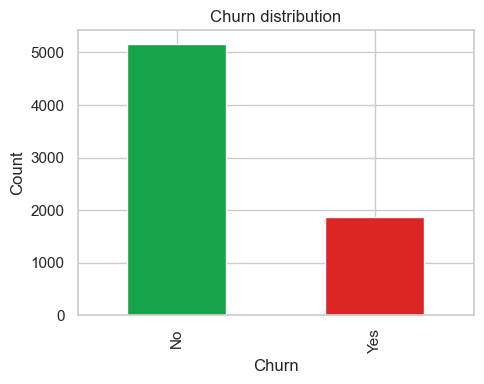

In [24]:
churn_rate = (clean["Churn"] == "Yes").mean() # gives the number of customers who are opting out of the service as churn == yes means customers that are churned or have left the service
# Churn rate is the percentage of customers who have opted out of the service. 
print(f"Churn rate: {churn_rate:.1%}") # Churn rate can often help in understanding if the dataset is balanced or imbalanced. 
# If the number of No are way higher than than Yes, then it shows signs of class imbalance in the dataset.

# If the number of Yes and No are not balanced, we will need to use techniques 
# to handle class imbalance in the dataset.

# It is important to handle class imbalance because if the model is trained on 
# an imbalanced dataset, it may become biased towards the majority class 
# and poorly predict the minority class which could often be the defining factor in the business problem. 

# In business, missing a churning customer (predicting No when it should be Yes) 
# is costly as the company loses a customer they could have retained. So correctly 
# predicting the minority class is more important than overall accuracy.

fig, ax = plt.subplots(figsize=(5, 4))
clean["Churn"].value_counts().plot(kind="bar", ax=ax, color=["#16a34a", "#dc2626"])
ax.set_title("Churn distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [33]:
print (clean.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


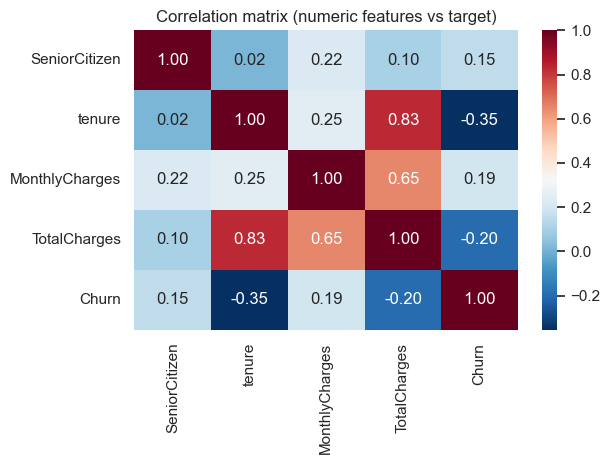


gender:
gender
Female    0.270
Male      0.262
Name: Churn, dtype: float64

Partner:
Partner
No     0.330
Yes    0.197
Name: Churn, dtype: float64

Dependents:
Dependents
No     0.313
Yes    0.155
Name: Churn, dtype: float64

PhoneService:
PhoneService
No     0.250
Yes    0.267
Name: Churn, dtype: float64

MultipleLines:
MultipleLines
No                  0.251
No phone service    0.250
Yes                 0.286
Name: Churn, dtype: float64

InternetService:
InternetService
DSL            0.190
Fiber optic    0.419
No             0.074
Name: Churn, dtype: float64

OnlineSecurity:
OnlineSecurity
No                     0.418
No internet service    0.074
Yes                    0.146
Name: Churn, dtype: float64

OnlineBackup:
OnlineBackup
No                     0.399
No internet service    0.074
Yes                    0.216
Name: Churn, dtype: float64

DeviceProtection:
DeviceProtection
No                     0.391
No internet service    0.074
Yes                    0.225
Name: Churn, dtype

In [35]:
# To understand the relationships between all numeric features and the target variable (which is the churn rate)
numeric_cols = clean.select_dtypes(include="number").copy()
numeric_cols["Churn"] = (clean["Churn"] == "Yes").astype(int)

sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("Correlation matrix (numeric features vs target)")
plt.tight_layout()
plt.show()

# Churn rate per categorical column
cat_cols = clean.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    if col != "Churn":  # skip the target column
        churn_rate = clean.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
        print(f"\n{col}:")
        print(churn_rate.round(3))

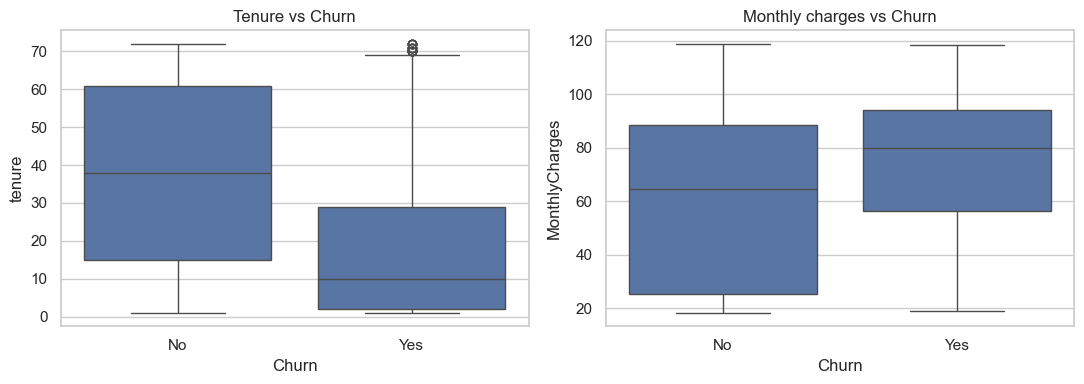

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=clean, x="Churn", y="tenure", ax=axes[0]) # Compares how long customers stayed (tenure in months) between churned and non-churned groups.
axes[0].set_title("Tenure vs Churn")
sns.boxplot(data=clean, x="Churn", y="MonthlyCharges", ax=axes[1]) # Compares the monthly charges between churned and non-churned groups. Higher monthly charges may be associated with higher churn rates. 
axes[1].set_title("Monthly charges vs Churn")
plt.tight_layout()
plt.show()

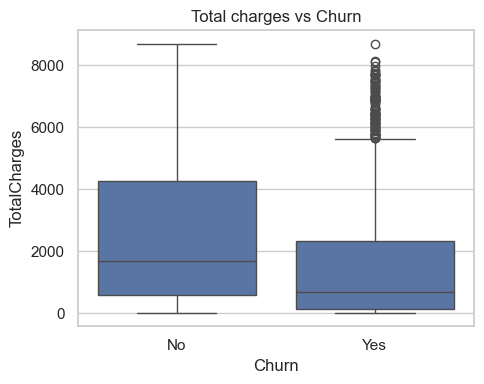

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=clean, x="Churn", y="TotalCharges", ax=ax) # To check if churned customer have lower or higher total charges than the non churned customers.
ax.set_title("Total charges vs Churn")
plt.tight_layout()
plt.show()

This could possible be because the customers leave before accumulating the total spend as compared to customers who stay. 

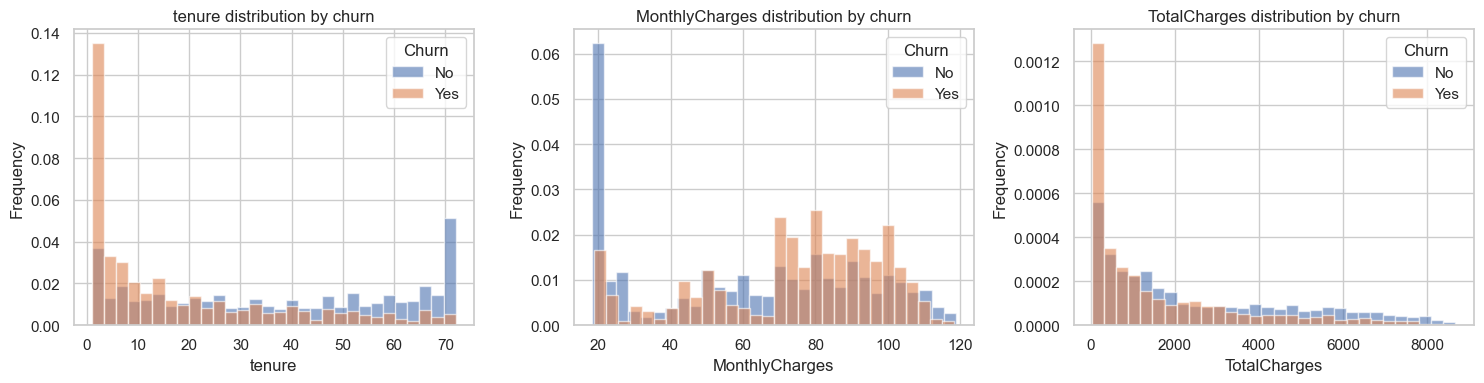

In [27]:
# Overlapping density plots reveal shape differences 
# density=True normalises both groups so the different class sizes don't distort the comparison
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for label, grp in clean.groupby("Churn"):
        grp[col].plot(kind="hist", ax=ax, alpha=0.6, bins=30,
                      label=label, density=True)
    ax.set_title(f"{col} distribution by churn")
    ax.set_xlabel(col)
    ax.legend(title="Churn")
plt.tight_layout()
plt.show()


As seen, churners seem to cluster at low tenure and high monthly charges. 

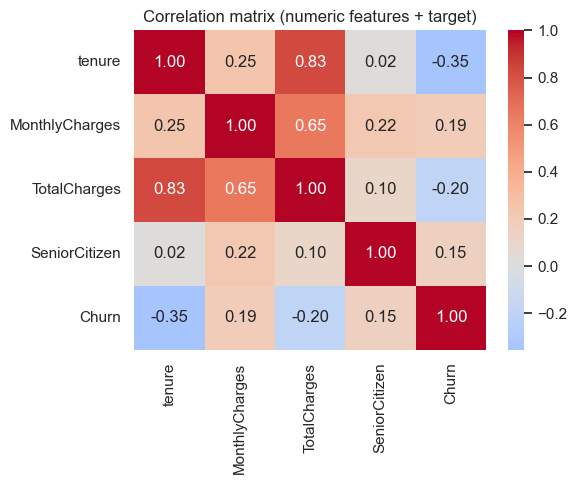

In [ ]:
# Correlation matrix of numeric features and target to understand relationships
corr_df = clean[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]].copy()
corr_df["Churn"] = (clean["Churn"] == "Yes").astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.show()

1. TotalCharges correlates strongly with tenure (longer customers accumulate more spend), potential multicollinearity as this can affect the model prediction. 

2. Tenure has the strongest negative correlation with churn which means that the longer a customer stays, the less likely they are to leave. 

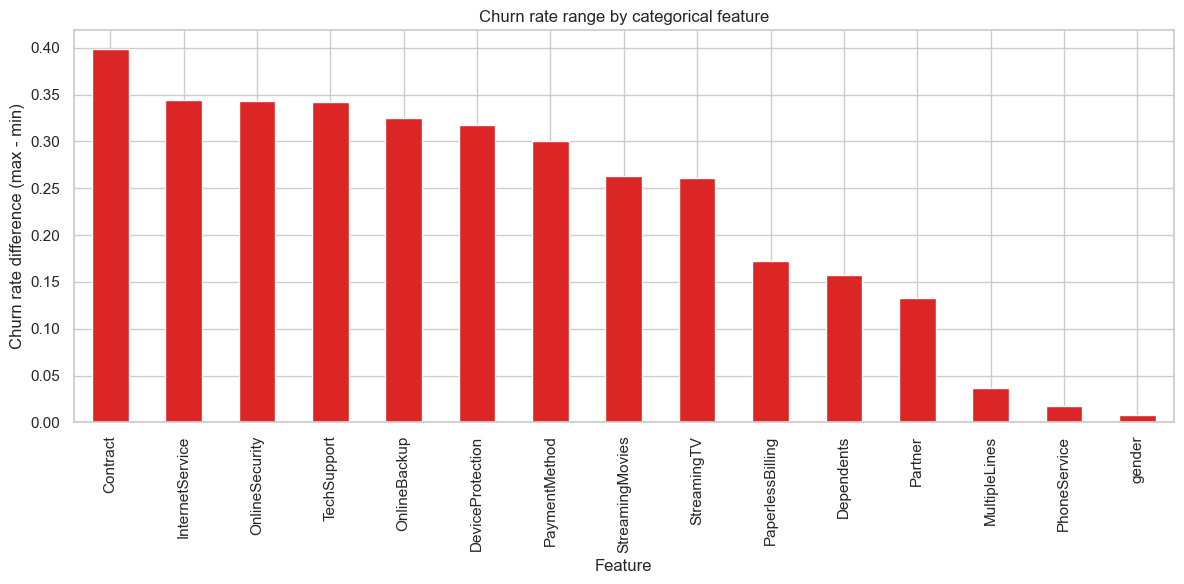

In [40]:
# Plotting bar plot to understand correlation of categorical features
cat_cols = clean.select_dtypes(include="object").columns.tolist()
cat_cols = [col for col in cat_cols if col != "Churn"]

churn_rates = {}
for col in cat_cols:
    rate = clean.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rates[col] = rate.max() - rate.min()  # range of churn rate across categories

# Plot
churn_impact = pd.Series(churn_rates).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
churn_impact.plot(kind="bar", ax=ax, color="#dc2626")
ax.set_title("Churn rate range by categorical feature")
ax.set_ylabel("Churn rate difference (max - min)")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.show()

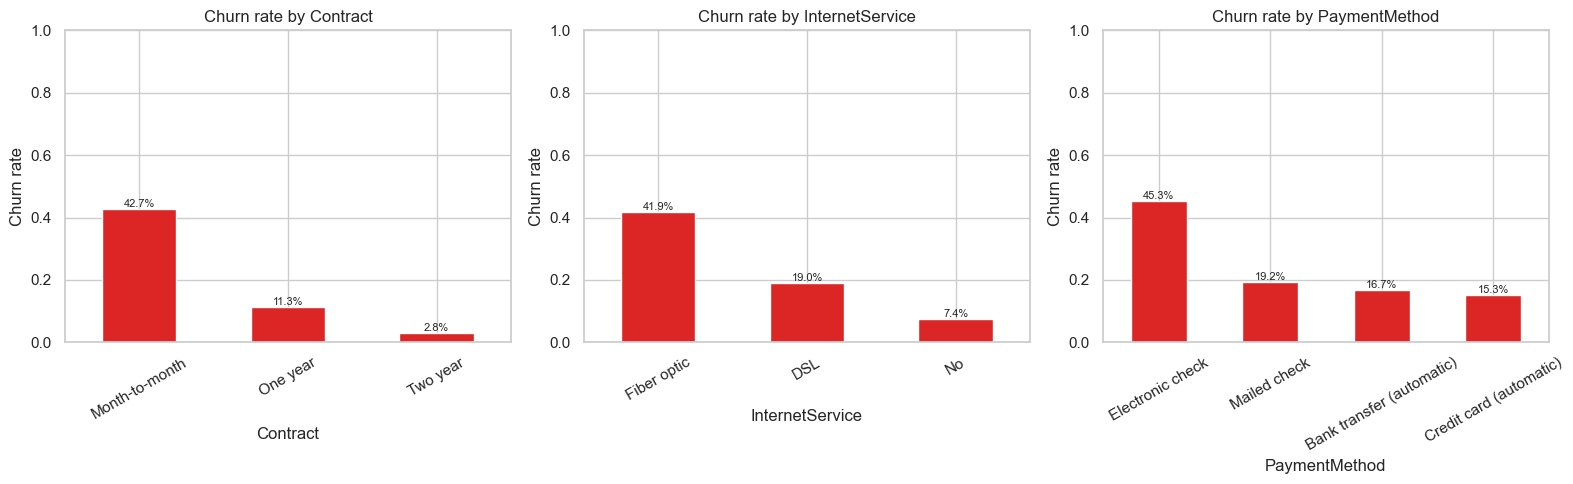

In [ ]:
# Understanding categorical features and their relationship with the target variable (churn rate)
cat_cols = ["Contract", "InternetService", "PaymentMethod"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    rates = (
        clean.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
    )
    rates.plot(kind="bar", ax=ax, color="#dc2626", edgecolor="white")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1%}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

1. Contract type is the single strongest predictor: month-to-month customers churn ~42% vs ~3% on two-year contracts
2. Electronic check payments also skew heavily toward churners 

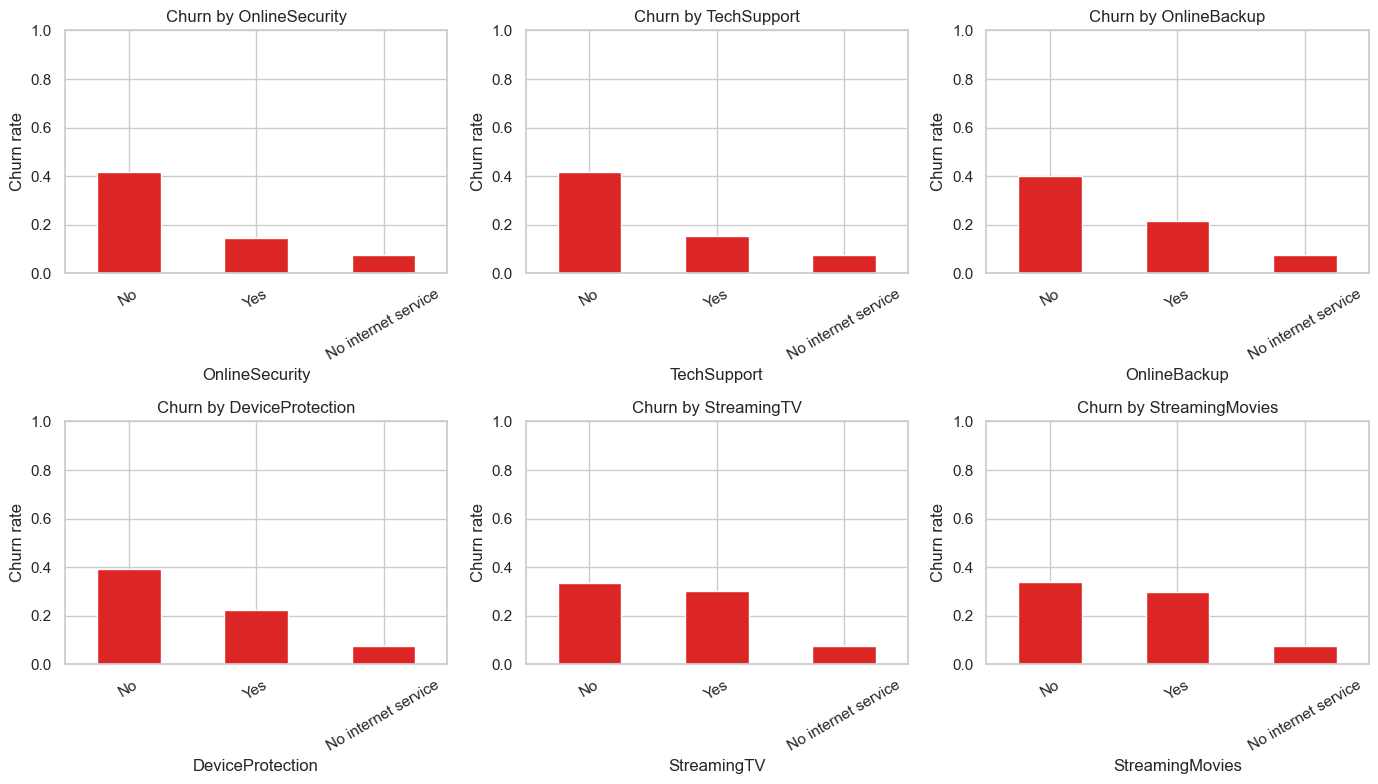

In [42]:
service_cols = ["OnlineSecurity", "TechSupport", "OnlineBackup",
                "DeviceProtection", "StreamingTV", "StreamingMovies"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, service_cols):
    rates = (
        clean.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
    )
    rates.plot(kind="bar", ax=ax, color="#dc2626", edgecolor="white")
    ax.set_title(f"Churn by {col}")
    ax.set_ylabel("Churn rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

1. Customers without protective services (security, support, backup) churn at nearly 2x the rate of those with them
2. "No internet service" rows are a third category and are worth noting but not a real service-usage signal

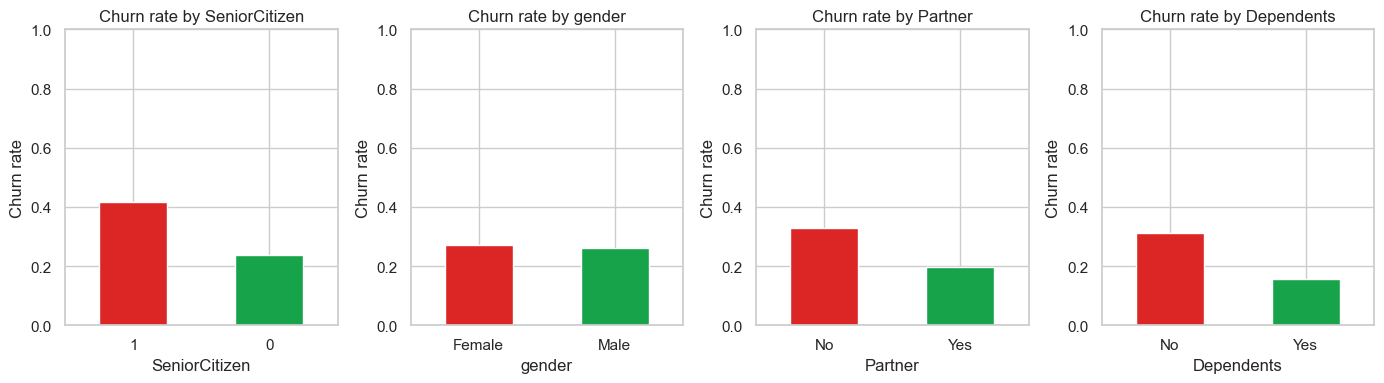

In [ ]:
# Analyzing churn rate per demographic features
demo_cols = ["SeniorCitizen", "gender", "Partner", "Dependents"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, demo_cols):
    rates = (
        clean.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
    )
    rates.plot(kind="bar", ax=ax, color=["#dc2626", "#16a34a"], edgecolor="white")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

Senior citizens churn at ~42% vs ~24% for non-seniors; living alone (no partner/dependents) also elevates risk

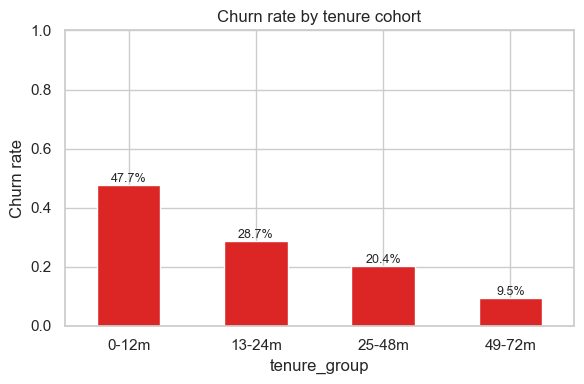

In [44]:

clean["tenure_group"] = pd.cut(
    clean["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12m", "13-24m", "25-48m", "49-72m"],
    include_lowest=True,
)
churn_by_tenure = (
    clean.groupby("tenure_group", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean())
)

fig, ax = plt.subplots(figsize=(6, 4))
churn_by_tenure.plot(kind="bar", ax=ax, color="#dc2626", edgecolor="white")
ax.set_title("Churn rate by tenure cohort")
ax.set_ylabel("Churn rate")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

1. "First-year cliff": nearly half of customers in the 0-12 month cohort churn, loyalty only stabilises sharply after year two